# Problem 4 - Statement 1
## Thống kê tổng doanh số và số lượng hóa đơn xử lý thành công theo từng nhân viên bán hàng

**Đề bài:** *Thống kê tổng doanh số kinh doanh và số lượng hóa đơn được xử lý thành công bởi từng nhân sự bán hàng (SalesPersonID).*

**Nguồn dữ liệu (silver, đã chuẩn hóa 3NF):**
- `ORDER` (order_id PK; FK: customer_id, zip, sales_employee_id; order_date, order_status, device_type, order_source)
- `ORDER_ITEMS` (order_id + product_id PK; quantity, unit_price, discount_amount)

**Framework áp dụng:** Measure → Metric → KPI
| Bước | Nội dung |
|---|---|
| Measure | Cột số liệu thô: `quantity`, `unit_price`, `discount_amount` (ORDER_ITEMS); `order_id`, `order_status`, `sales_employee_id` (ORDER) |
| Metric | Hàm tổng hợp theo `sales_employee_id`: `SUM(doanh_thu_dòng)`, `COUNT(DISTINCT order_id)` |
| KPI | Tổng doanh số/nhân viên, Số hóa đơn thành công/nhân viên, Doanh thu trung bình/hóa đơn |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load dữ liệu (silver layer)

Chỉnh lại đường dẫn/nguồn dữ liệu cho phù hợp với silver data thực tế của nhóm
(CSV, Parquet, hoặc kết nối database). Mặc định bên dưới đọc từ CSV trong thư mục `data/`.


In [2]:
# --- CHỈNH LẠI ĐƯỜNG DẪN CHO PHÙ HỢP VỚI SILVER DATA CỦA NHÓM ---
ORDER_PATH = "DAAI_N1.4/silver_data/ORDER.csv"
ORDER_ITEMS_PATH = "DAAI_N1.4/silver_data/ORDER_ITEMS.csv"

df_order = pd.read_csv(ORDER_PATH, parse_dates=["order_date"])
df_items = pd.read_csv(ORDER_ITEMS_PATH)

print("ORDER:", df_order.shape)
print("ORDER_ITEMS:", df_items.shape)


ORDER: (646945, 8)
ORDER_ITEMS: (714653, 5)


## 2. Khám phá sơ bộ dữ liệu

Kiểm tra cấu trúc, kiểu dữ liệu, và đặc biệt là các giá trị của `order_status`
để xác định đâu là trạng thái "xử lý thành công".


In [3]:
display(df_order.head())
display(df_items.head())

print("Các giá trị order_status:")
print(df_order["order_status"].value_counts(dropna=False))


,order_id,order_date,customer_id,zip,order_status,device_type,order_source,sales_employee_id
0,1,2012-07-04,58578,1109,delivered,desktop,paid_search,EMP0103
1,2,2012-07-04,58621,1330,returned,mobile,paid_search,EMP0180
2,3,2012-07-04,58811,1473,delivered,desktop,direct,EMP0093
3,4,2012-07-04,59453,2360,delivered,desktop,referral,EMP0015
4,6,2012-07-06,57821,2886,delivered,mobile,email_campaign,EMP0107


,order_id,product_id,quantity,unit_price,discount_amount
0,1,2400,7,"1,138.22",0.00
1,2,609,7,"10,166.25",0.00
2,3,396,3,"11,220.33",0.00
3,4,635,5,"10,639.25",0.00
4,6,1935,1,"1,597.84",0.00


Các giá trị order_status:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [4]:
# Kiểm tra dữ liệu thiếu / trùng lặp trên các cột liên quan
print("Số dòng ORDER thiếu sales_employee_id:", df_order["sales_employee_id"].isna().sum())
print("Số dòng ORDER_ITEMS thiếu quantity/unit_price:",
      df_items[["quantity", "unit_price"]].isna().any(axis=1).sum())
print("Số order_id trùng trong ORDER:", df_order["order_id"].duplicated().sum())


Số dòng ORDER thiếu sales_employee_id: 0
Số dòng ORDER_ITEMS thiếu quantity/unit_price: 0
Số order_id trùng trong ORDER: 0


## 3. Xác định Measure

Các measure (số liệu thô, chưa tổng hợp) tham gia giải quyết statement này:

| Bảng | Measure | Ý nghĩa |
|---|---|---|
| ORDER | `sales_employee_id` | Định danh nhân viên bán hàng — chiều phân tích (dimension) |
| ORDER | `order_status` | Trạng thái đơn hàng — để lọc "xử lý thành công" |
| ORDER | `order_id` | Định danh hóa đơn/đơn hàng |
| ORDER_ITEMS | `quantity` | Số lượng sản phẩm trong 1 dòng hàng |
| ORDER_ITEMS | `unit_price` | Đơn giá sản phẩm |
| ORDER_ITEMS | `discount_amount` | Số tiền chiết khấu trên dòng hàng |

Từ đó tính measure dẫn xuất ở mức dòng hàng: `doanh_thu_dong = quantity * unit_price - discount_amount`.


In [5]:
df_items["doanh_thu_dong"] = (
    df_items["quantity"] * df_items["unit_price"] - df_items["discount_amount"]
)
df_items[["order_id", "product_id", "quantity", "unit_price", "discount_amount", "doanh_thu_dong"]].head()


,order_id,product_id,quantity,unit_price,discount_amount,doanh_thu_dong
0,1,2400,7,"1,138.22",0.00,"7,967.54"
1,2,609,7,"10,166.25",0.00,"71,163.75"
2,3,396,3,"11,220.33",0.00,"33,660.99"
3,4,635,5,"10,639.25",0.00,"53,196.25"
4,6,1935,1,"1,597.84",0.00,"1,597.84"


## 4. Lọc hóa đơn "xử lý thành công"

Danh sách trạng thái được coi là "xử lý thành công" cần đối chiếu với dữ liệu thực tế
ở bước 2 (`value_counts` của `order_status`). Cập nhật `SUCCESSFUL_STATUSES` bên dưới cho khớp.


In [9]:
# --- CẬP NHẬT DANH SÁCH TRẠNG THÁI THÀNH CÔNG CHO KHỚP VỚI DỮ LIỆU THỰC TẾ ---
SUCCESSFUL_STATUSES = ["delivered"]

df_order_success = df_order[df_order["order_status"].isin(SUCCESSFUL_STATUSES)].copy()
print(f"Số đơn hàng thành công: {len(df_order_success):,} / {len(df_order):,}")


Số đơn hàng thành công: 516,716 / 646,945


## 5. Xây dựng Metric

Nối `ORDER_ITEMS` với các đơn hàng thành công qua `order_id`, sau đó tổng hợp
(`SUM`, `COUNT DISTINCT`) theo `sales_employee_id`.


In [10]:
df_merged = df_items.merge(
    df_order_success[["order_id", "sales_employee_id", "order_date"]],
    on="order_id",
    how="inner",
)

metric_by_employee = (
    df_merged.groupby("sales_employee_id")
    .agg(
        tong_doanh_so=("doanh_thu_dong", "sum"),
        so_hoa_don_thanh_cong=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values("tong_doanh_so", ascending=False)
)

metric_by_employee.head(10)


,sales_employee_id,tong_doanh_so,so_hoa_don_thanh_cong
142,EMP0143,"67,447,041.59",2736
162,EMP0163,"66,987,174.61",2623
139,EMP0140,"66,836,073.98",2637
57,EMP0058,"66,801,686.74",2635
130,EMP0131,"66,716,424.79",2634
161,EMP0162,"66,588,531.36",2655
132,EMP0133,"66,550,669.11",2679
52,EMP0053,"66,516,399.77",2645
168,EMP0169,"66,483,455.48",2630
155,EMP0156,"66,405,996.62",2664


## 6. Xây dựng KPI

Kết hợp các metric ở trên thành bộ KPI đánh giá năng lực thúc đẩy doanh số của từng nhân viên:

- **Tổng doanh số** (`tong_doanh_so`) — quy mô đóng góp doanh thu.
- **Số hóa đơn xử lý thành công** (`so_hoa_don_thanh_cong`) — khối lượng công việc/độ hoạt động.
- **Doanh thu trung bình/hóa đơn** (`doanh_thu_tb_hoa_don`) — chất lượng/giá trị mỗi giao dịch.
- **Xếp hạng** (`rank_doanh_so`) — thứ hạng nhân viên theo tổng doanh số.


In [11]:
kpi_table = metric_by_employee.copy()
kpi_table["doanh_thu_tb_hoa_don"] = (
    kpi_table["tong_doanh_so"] / kpi_table["so_hoa_don_thanh_cong"]
)
kpi_table["rank_doanh_so"] = kpi_table["tong_doanh_so"].rank(ascending=False, method="dense").astype(int)

kpi_table = kpi_table.sort_values("rank_doanh_so")
kpi_table.head(10)


,sales_employee_id,tong_doanh_so,so_hoa_don_thanh_cong,doanh_thu_tb_hoa_don,rank_doanh_so
142,EMP0143,"67,447,041.59",2736,"24,651.70",1
162,EMP0163,"66,987,174.61",2623,"25,538.38",2
139,EMP0140,"66,836,073.98",2637,"25,345.50",3
57,EMP0058,"66,801,686.74",2635,"25,351.68",4
130,EMP0131,"66,716,424.79",2634,"25,328.94",5
161,EMP0162,"66,588,531.36",2655,"25,080.43",6
132,EMP0133,"66,550,669.11",2679,"24,841.61",7
52,EMP0053,"66,516,399.77",2645,"25,147.98",8
168,EMP0169,"66,483,455.48",2630,"25,278.88",9
155,EMP0156,"66,405,996.62",2664,"24,927.18",10


## 7. Trực quan hóa

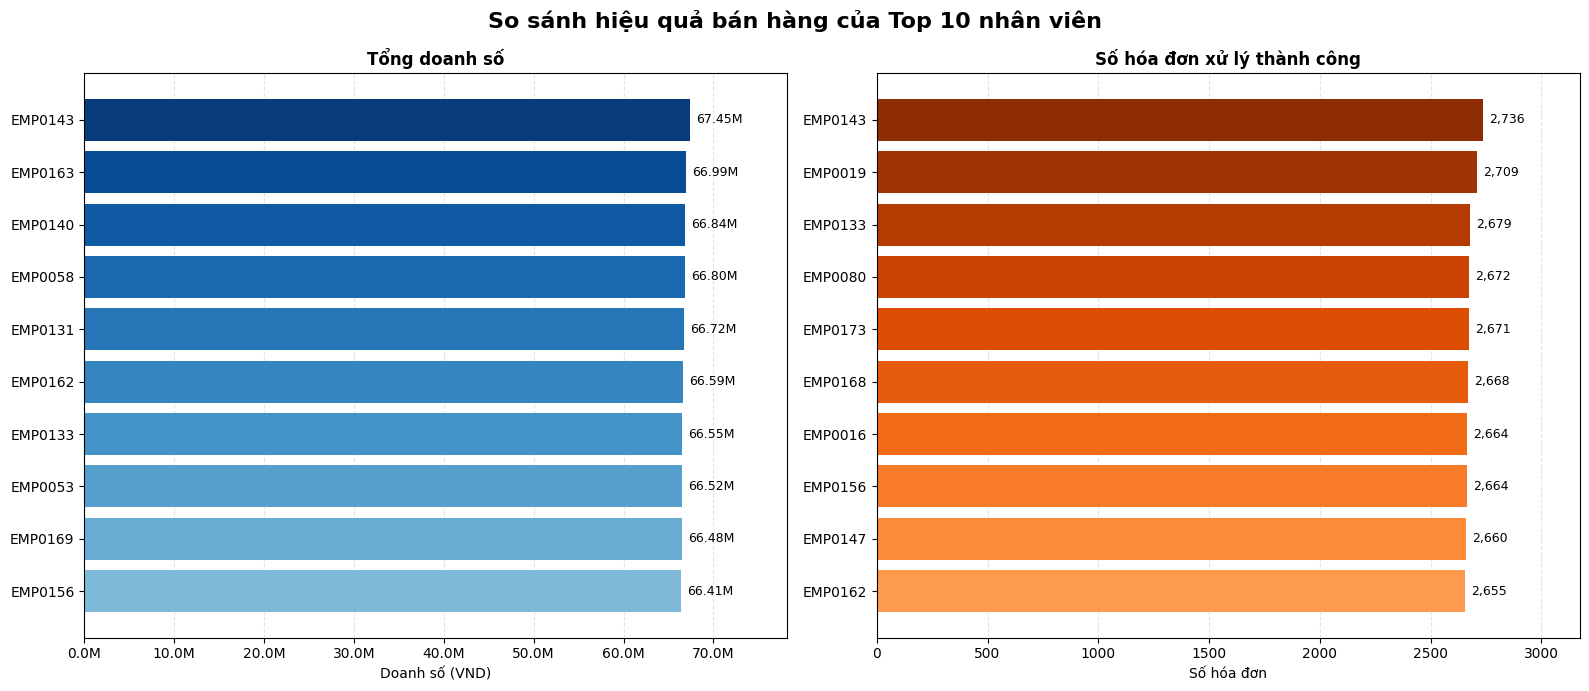

In [14]:
top_n = 10

# Sắp xếp riêng theo từng KPI để thứ hạng và độ dài thanh dễ so sánh.
top_revenue = kpi_table.nlargest(top_n, "tong_doanh_so").sort_values("tong_doanh_so")
top_orders = kpi_table.nlargest(top_n, "so_hoa_don_thanh_cong").sort_values("so_hoa_don_thanh_cong")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("So sánh hiệu quả bán hàng của Top 10 nhân viên", fontsize=16, fontweight="bold")

revenue_colors = plt.cm.Blues(np.linspace(0.45, 0.95, len(top_revenue)))
order_colors = plt.cm.Oranges(np.linspace(0.45, 0.95, len(top_orders)))

revenue_bars = axes[0].barh(
    top_revenue["sales_employee_id"].astype(str),
    top_revenue["tong_doanh_so"],
    color=revenue_colors,
)
axes[0].set_title("Tổng doanh số", fontweight="bold")
axes[0].set_xlabel("Doanh số (VND)")
axes[0].grid(axis="x", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:.1f}M"))
axes[0].set_xlim(0, top_revenue["tong_doanh_so"].max() * 1.16)
for bar, value in zip(revenue_bars, top_revenue["tong_doanh_so"]):
    axes[0].text(
        bar.get_width() + top_revenue["tong_doanh_so"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1e6:.2f}M",
        va="center",
        fontsize=9,
    )

order_bars = axes[1].barh(
    top_orders["sales_employee_id"].astype(str),
    top_orders["so_hoa_don_thanh_cong"],
    color=order_colors,
)
axes[1].set_title("Số hóa đơn xử lý thành công", fontweight="bold")
axes[1].set_xlabel("Số hóa đơn")
axes[1].grid(axis="x", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)
axes[1].set_xlim(0, top_orders["so_hoa_don_thanh_cong"].max() * 1.16)
for bar, value in zip(order_bars, top_orders["so_hoa_don_thanh_cong"]):
    axes[1].text(
        bar.get_width() + top_orders["so_hoa_don_thanh_cong"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## 8. Xuất kết quả

In [15]:
OUTPUT_PATH = "DAAI_N1.4/problem_statements/output/ps1_kpi_by_employee.csv"
kpi_table.to_csv(OUTPUT_PATH, index=False)
print(f"Đã lưu bảng KPI vào: {OUTPUT_PATH}")


Đã lưu bảng KPI vào: DAAI_N1.4/problem_statements/output/ps1_kpi_by_employee.csv
